In [1]:
# Cell 1: 导入库
import torch
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import gaussian_filter
import deepwave

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
plt.rcParams['font.family'] = ['Times New Roman', 'DejaVu Serif', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font.size'] = 14

import os, sys, time

from example_to_dyy.funcs import draw_kernels

v_true shape: (180, 120), max_vel=4242.5, min_vel=1500.0
fix_upper_layer shape: (180, 25) (水层)
v_smth shape: (180, 120)


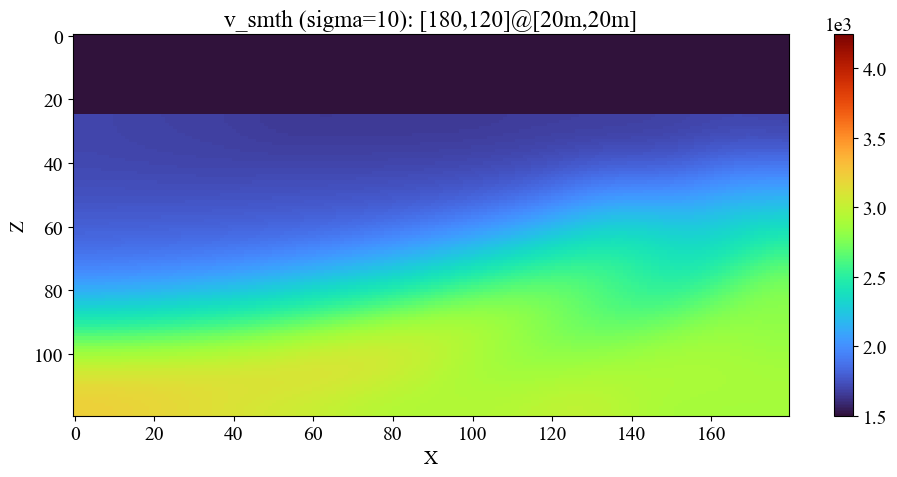

In [4]:
# Cell 2: 加载 Marmousi 模型并裁剪 + 高斯平滑得到 v_smth (180x120)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
cm_v = 'turbo'
cm_r = 'gray'
figsize = (10, 5)

# 原始模型参数
nx, nz = 541, 176
dx, dz = 20.0, 20.0
wl = 25  # 水层厚度 (网格点数)

# 读取原始 Marmousi
v_true_raw = torch.from_file('example_to_dyy/models/v_true_zm25.dat',
                             size=nx * nz, dtype=dtype).reshape(nx, nz).to(device)

# 裁剪到 180x120 (test_model_build 的设定)
clip_nx, start_x = 180, 120
clip_nz = 120
v_true = v_true_raw[start_x:start_x + clip_nx, 0:clip_nz].contiguous()
max_vel = v_true.max().item()
min_vel = 1500.0
norm_v = colors.Normalize(vmax=max_vel, vmin=min_vel)
print(f"v_true shape: {tuple(v_true.shape)}, max_vel={max_vel:.1f}, min_vel={min_vel:.1f}")

# 固定水层 (在 B-spline 插值时不修改)
fix_upper_layer = v_true[:, :wl].clone()
print(f"fix_upper_layer shape: {tuple(fix_upper_layer.shape)} (水层)")

# 对地下部分做高斯平滑 sigma=3，与水层拼接得到 v_smth
sigma = 10
v_smth = torch.cat((
    v_true[:, :wl],
    torch.tensor(gaussian_filter(v_true[:, wl:].cpu().numpy(), sigma=sigma),
                 dtype=dtype).to(device)
), dim=1)
print(f"v_smth shape: {tuple(v_smth.shape)}")

draw_kernels.draw_snap(v_smth, figsize=figsize, cmap=cm_v, norm=norm_v,
                       title=f"v_smth (sigma={sigma}): [180,120]@[20m,20m]")

v_sub (地下部分) shape: (180, 95)
[B-spline inverse CG] it=01, rel_res=1.218e-01
[B-spline inverse CG] it=02, rel_res=3.675e-02
[B-spline inverse CG] it=03, rel_res=3.021e-02
[B-spline inverse CG] it=04, rel_res=1.325e-02
[B-spline inverse CG] it=05, rel_res=5.004e-03
[B-spline inverse CG] it=06, rel_res=2.755e-03
[B-spline inverse CG] it=07, rel_res=2.860e-03
[B-spline inverse CG] it=08, rel_res=1.584e-03
[B-spline inverse CG] it=09, rel_res=1.025e-03
[B-spline inverse CG] it=10, rel_res=8.684e-04
[B-spline inverse CG] it=11, rel_res=6.592e-04
[B-spline inverse CG] it=12, rel_res=7.575e-04
[B-spline inverse CG] it=13, rel_res=8.239e-04
[B-spline inverse CG] it=14, rel_res=3.254e-04
[B-spline inverse CG] it=15, rel_res=4.349e-04
[B-spline inverse CG] it=16, rel_res=2.950e-04
[B-spline inverse CG] it=17, rel_res=2.794e-04
[B-spline inverse CG] it=18, rel_res=1.104e-04
[B-spline inverse CG] it=19, rel_res=2.415e-04
[B-spline inverse CG] it=20, rel_res=1.362e-04
[B-spline inverse CG] it=21, r

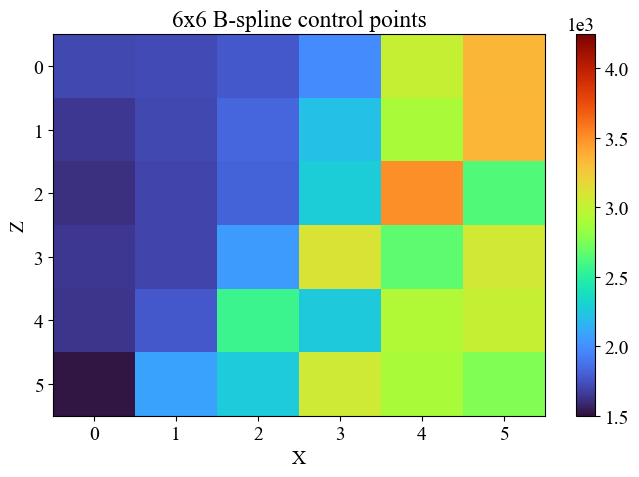

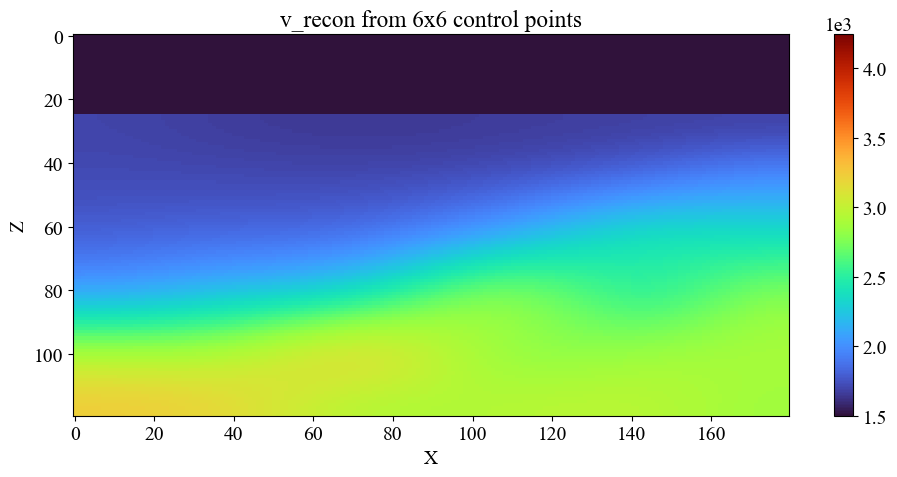

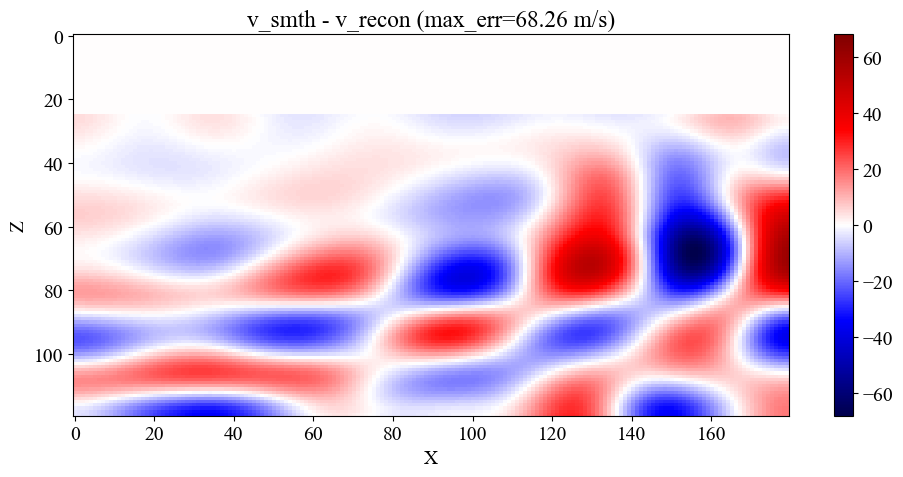

In [5]:
# Cell 3: B-spline inverse -> 6x6 控制点 + 重建可视化
from agents.Bspline import bspline2d_inverse, bspline2d_prolong

# 对地下部分 (180, 95) 做 B-spline inverse 得到 6x6 控制点
# bspline2d_inverse: dense (Hd, Wd) -> sparse (Hc, Wc)
v_sub = v_smth[:, wl:]  # (180, 95)
print(f"v_sub (地下部分) shape: {tuple(v_sub.shape)}")

c_6x6 = bspline2d_inverse(v_sub, (6, 6), lam=1e-2, maxit=200,
                          tol=1e-12, verbose=True)
print(f"c_6x6 shape: {tuple(c_6x6.shape)}, "
      f"value range: [{c_6x6.min().item():.1f}, {c_6x6.max().item():.1f}]")

# 从 6x6 控制点重建地下部分
v_recon_sub = bspline2d_prolong(c_6x6, (180, 95))
print(f"v_recon_sub shape: {tuple(v_recon_sub.shape)}")

# 拼接水层得到完整重建模型
v_recon = torch.cat([v_smth[:, :wl], v_recon_sub], dim=1)
print(f"v_recon shape: {tuple(v_recon.shape)}")

# 可视化: 控制点 -> 完整重建模型
draw_kernels.draw_snap(c_6x6.T, figsize=(7, 5), cmap=cm_v, norm=norm_v,
                       title="6x6 B-spline control points")
draw_kernels.draw_snap(v_recon, figsize=figsize, cmap=cm_v, norm=norm_v,
                       title="v_recon from 6x6 control points")

# 残差
diff = v_smth - v_recon
vmax_diff = diff.abs().max().item()
norm_diff = colors.Normalize(vmax=vmax_diff, vmin=-vmax_diff)
draw_kernels.draw_snap(diff, figsize=figsize, cmap='seismic', norm=norm_diff,
                       title=f"v_smth - v_recon (max_err={vmax_diff:.2f} m/s)")

In [6]:
# Cell 4: 观测系统设定 (炮点不变, 检波器移到最底层 z=clip_nz-1)
n_shots = 36
n_sources_per_shot = 1
d_source = 5
first_source = 0
source_depth = 1  # z 方向最浅层 (z=1, 即地表以下 1 格)

is_tow = False
ng = 180                     # 检波器数量 = clip_nx
n_receivers_per_shot = ng
d_receiver = 1
first_receiver = 0
receiver_depth = clip_nz - 1  # z 方向最底层 (z=119)

freq = 10.0
nt = 1500
dt = 0.0036
peak_time = 0.3
A0 = 1.0
pml_width = [20, 20, 20, 20]
accuracy = 8

# 震源坐标: x 方向均匀分布, z 固定在 source_depth
source_locations = torch.zeros(n_shots, n_sources_per_shot, 2,
                               dtype=torch.int32, device=device)
source_locations[..., 1] = source_depth
source_locations[:, 0, 0] = torch.arange(n_shots) * d_source + first_source

# 检波器坐标: 固定在模型最底层 (z=clip_nz-1=119)
receiver_locations = torch.zeros(n_shots, n_receivers_per_shot, 2,
                                 dtype=torch.int32, device=device)
receiver_locations[..., 1] = receiver_depth
receiver_locations[:, :, 0] = (torch.arange(n_receivers_per_shot) * d_receiver
                               + first_receiver).repeat(n_shots, 1)

# 震源子波 (Ricker)
s_wavelet = A0 * deepwave.wavelets.ricker(freq, nt, dt, peak_time, dtype=dtype)
source_amplitudes = s_wavelet.repeat(n_shots, n_sources_per_shot, 1) \
                            .type(torch.float32).to(device)

print(f"观测系统概要:")
print(f"  炮数: {n_shots}, 炮间距: {d_source} 格 = {d_source*dx}m")
print(f"  检波器数: {ng}, 检波器深度 z={receiver_depth} ({receiver_depth*dz}m)")
print(f"  震源深度 z={source_depth} ({source_depth*dz}m)")
print(f"  震源 x 范围: [{source_locations[:, 0, 0].min().item()}, "
      f"{source_locations[:, 0, 0].max().item()}]")
print(f"  检波器 x 范围: [{receiver_locations[0, :, 0].min().item()}, "
      f"{receiver_locations[0, :, 0].max().item()}]")

观测系统概要:
  炮数: 36, 炮间距: 5 格 = 100.0m
  检波器数: 180, 检波器深度 z=119 (2380.0m)
  震源深度 z=1 (20.0m)
  震源 x 范围: [0, 175]
  检波器 x 范围: [0, 179]


shot_obs shape: (36, 180, 1500)


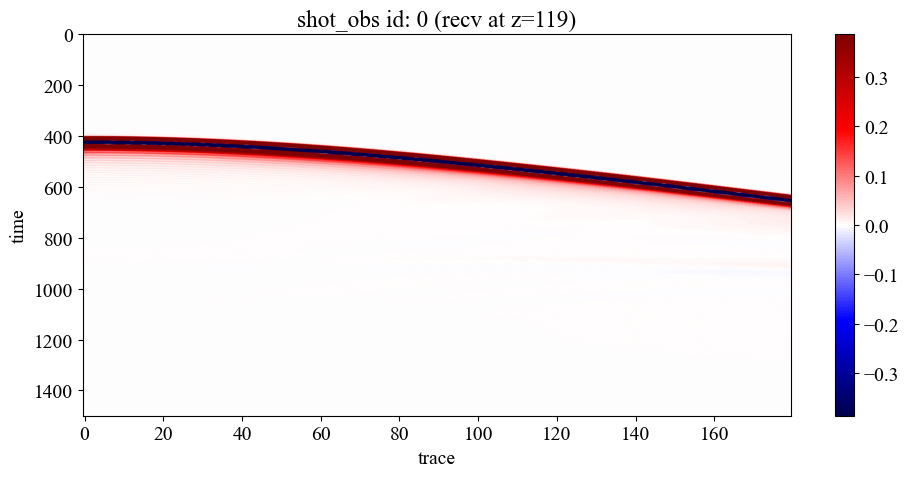

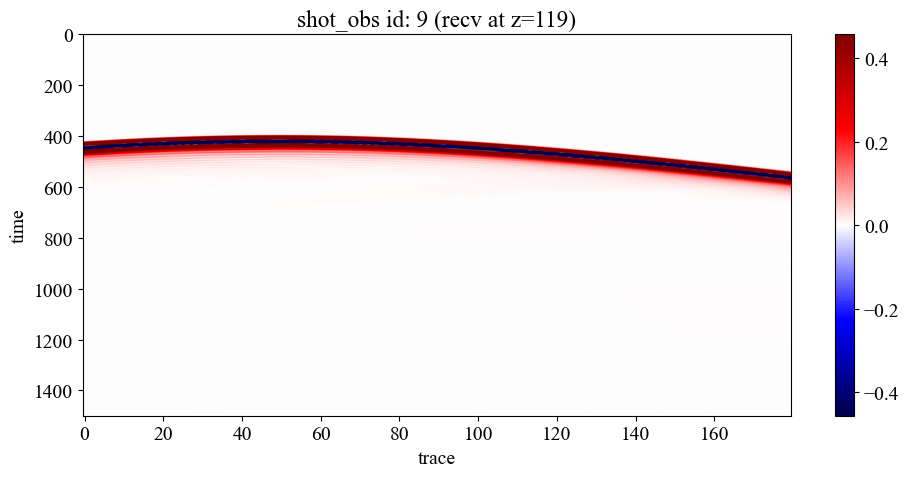

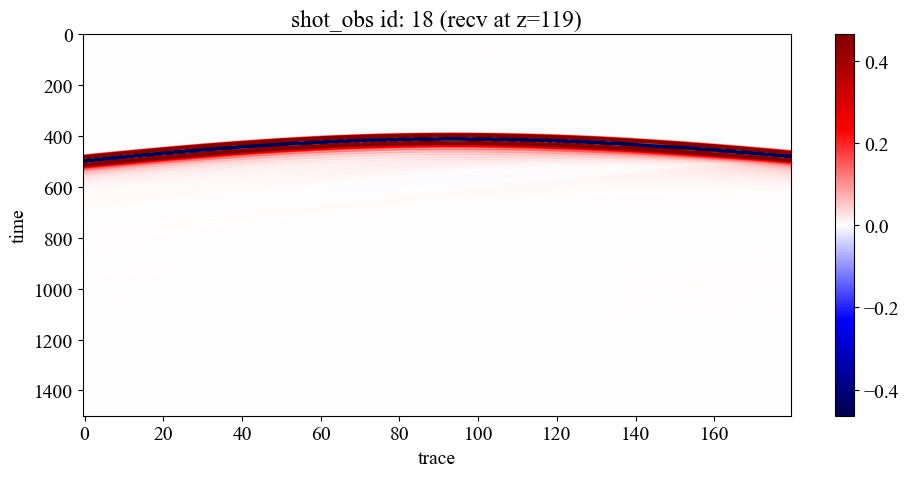

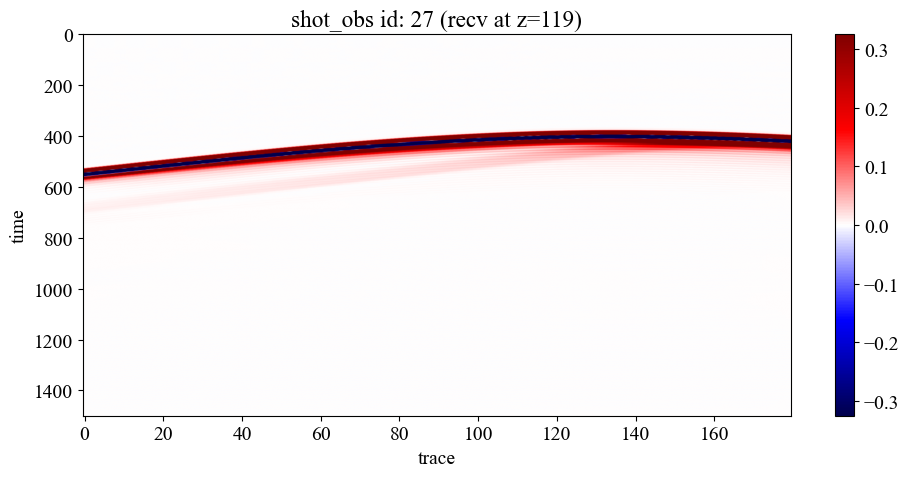

In [7]:
# Cell 5: 用 v_smth 做正演得到观测炮集 + 可视化
shot_obs = deepwave.scalar(
    v_smth,
    [dx, dz],
    dt,
    accuracy=accuracy,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    max_vel=max_vel,
    pml_width=pml_width,
    pml_freq=freq,
)[-1]
print(f"shot_obs shape: {tuple(shot_obs.shape)}")

# 可视化部分炮集
ids_list = [0, n_shots // 4, n_shots // 2, 3 * n_shots // 4]
for ids in ids_list:
    draw_kernels.draw_shot(shot_obs[ids],
                           title=f'shot_obs id: {ids} (recv at z={receiver_depth})')

shot_pred shape: (36, 180, 1500)
FWI reward = -6.79e+08
shot Mismatch MSE = 1.0654e-02


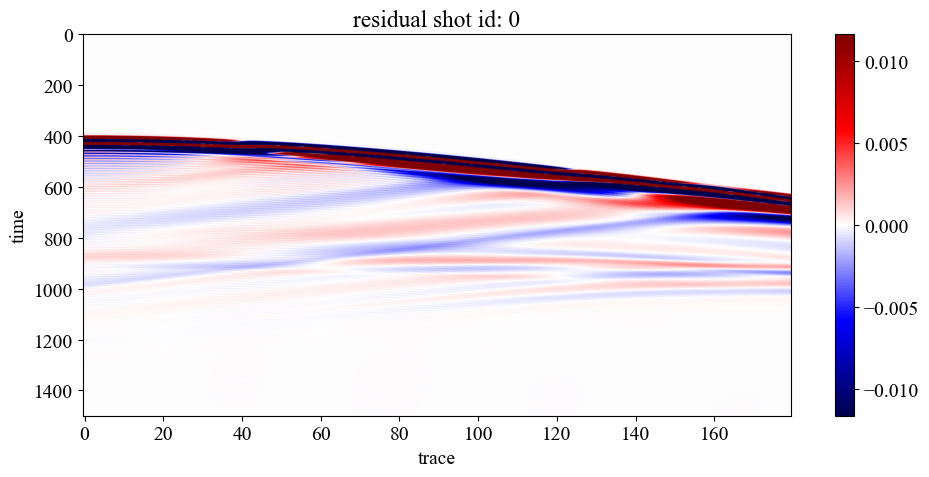

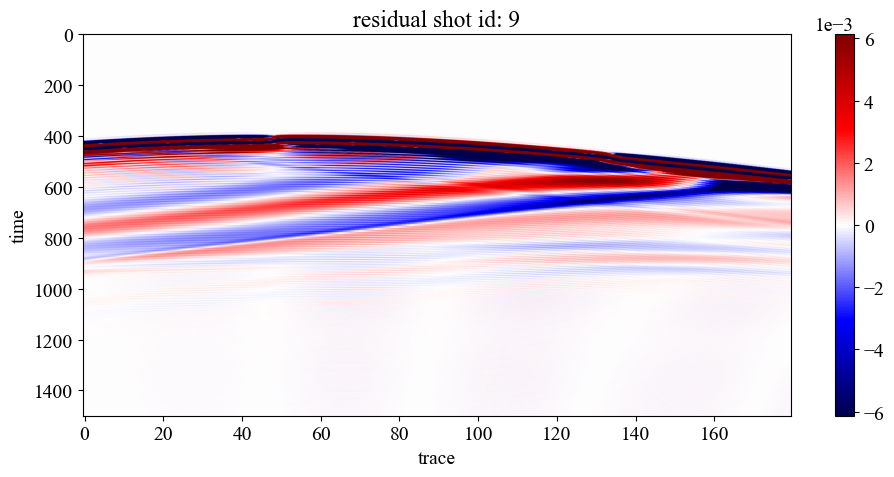

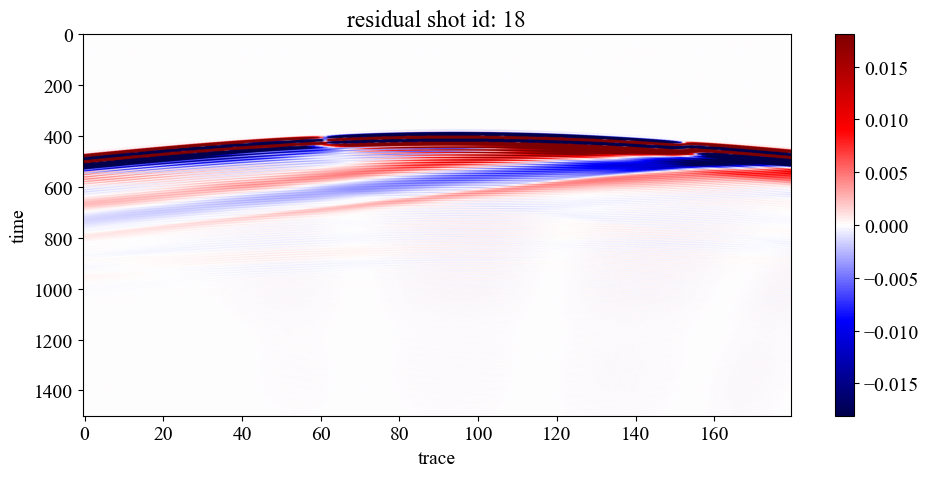

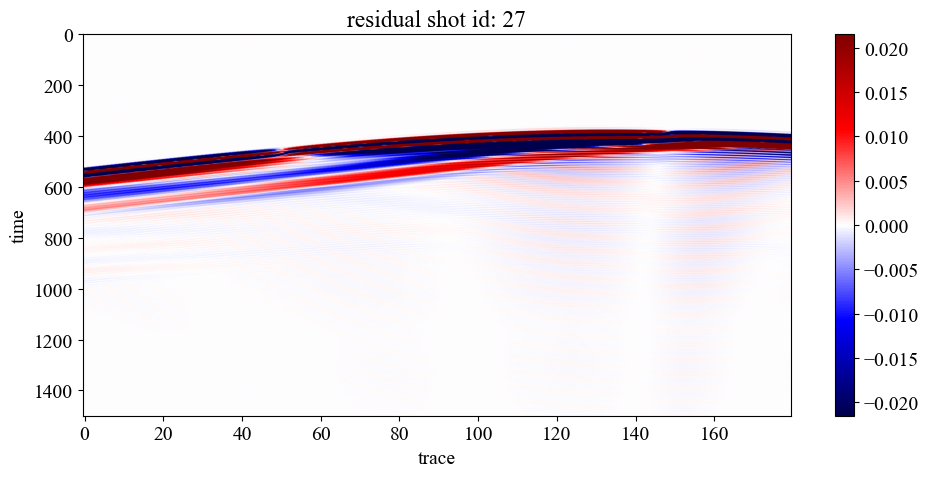

In [8]:
# Cell 6: 用 v_recon (6x6 重建) 做正演 + FWI loss
shot_pred = deepwave.scalar(
    v_recon,
    [dx, dz],
    dt,
    accuracy=accuracy,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    max_vel=max_vel,
    pml_width=pml_width,
    pml_freq=freq,
)[-1]
print(f"shot_pred shape: {tuple(shot_pred.shape)}")

# 残差可视化
for ids in ids_list:
    residual = shot_obs[ids] - shot_pred[ids]
    draw_kernels.draw_shot(residual, title=f'residual shot id: {ids}')

# FWI loss: sign-preserving log + L1 + L2
from agents.reward_calculator import reward_l1_l2_log

fwi_reward = reward_l1_l2_log(
    shot_pred.unsqueeze(0).to(device),
    shot_obs.unsqueeze(0).to(device),
    k=3.0, c=0.0,
)
print(f"FWI reward = {float(fwi_reward.item()):.2e}")

# 也计算简单 MSE
mse_val = torch.mean((shot_obs - shot_pred) ** 2).item()
print(f"shot Mismatch MSE = {mse_val:.4e}")

100%|██████████| 4/4 [00:03<00:00,  1.05it/s]
RTM's SI= 3.9923e+07
RTM finished! Stacked Image generated. 	[Cost time: 3.9192 seconds]
RTM SI (完整) = 3.9923e+07
SI energy (地下部分, sum(RTM^2)) = 3.8987e+07
SI energy (完整模型, sum(RTM^2)) = 3.9923e+07


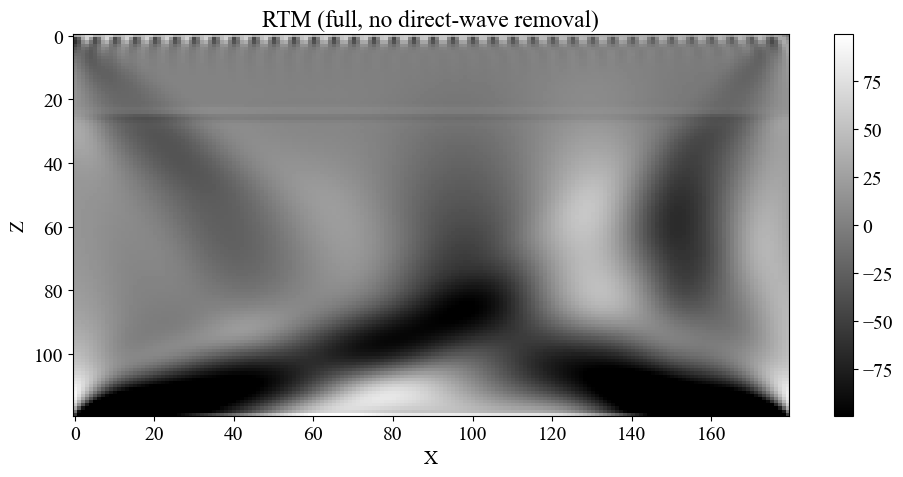

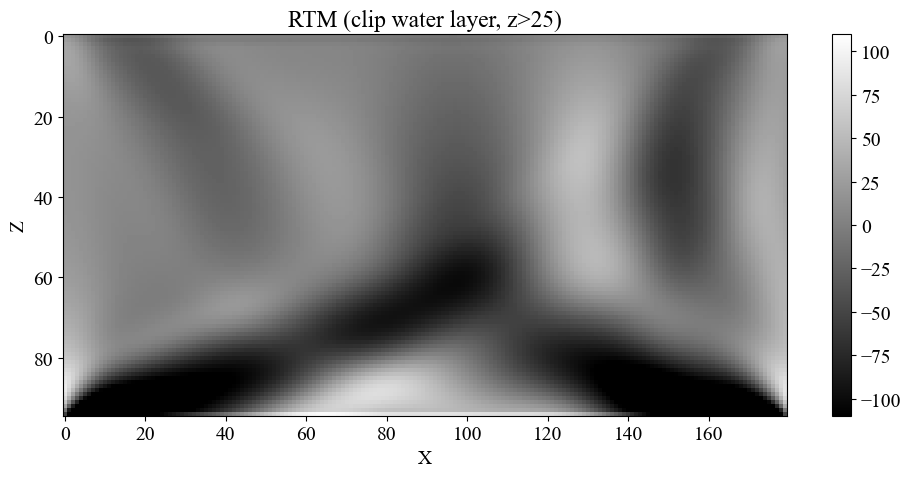

In [9]:
# Cell 7: 用 v_recon 做 RTM (不去直达波, 直接反传 shot_obs)
#   关键区别: obsv_data_masked 用完整的 shot_obs, 不像 self_build 那样 shot0 - shot_cons
from example_to_dyy.funcs import RTM
import importlib
importlib.reload(RTM)

rtm_image = torch.zeros_like(v_recon).to(device)
illum_mul = torch.zeros_like(v_recon).to(device)

SI = RTM.rtm_imaging_batch_all_forw(
    rtm_image,
    v_recon.to(device),           # 偏移速度模型 = 6x6 重建
    [dx, dz],
    dt,
    source_amplitudes,
    source_locations,
    shot_obs,                      # 直接传完整观测数据, 不去直达波!
    receiver_locations,
    batch_size=12,
    max_vel=max_vel,
    pml_freq=freq,
    callback_freq=1,
    illum=True,
    illum_mul=illum_mul,
    forw_dt2=False,
    outSI=True,
)
print(f"RTM SI (完整) = {SI:.4e}")

# --- 可视化 RTM (完整图像) ---
vmax_r = torch.quantile(rtm_image.abs(), 0.96).item()
norm_r = colors.Normalize(vmax=vmax_r, vmin=-vmax_r)
draw_kernels.draw_snap(rtm_image, cmap=cm_r, norm=norm_r, title='RTM (full, no direct-wave removal)')

# --- 可视化去掉水层后的 RTM ---
clip_upper_rtm = rtm_image[:, wl:]
q96 = torch.quantile(clip_upper_rtm.abs(), 0.96).item()
norm_rc = colors.Normalize(vmax=q96, vmin=-q96)
draw_kernels.draw_snap(clip_upper_rtm, cmap=cm_r, norm=norm_rc,
                       title=f'RTM (clip water layer, z>{wl})')

# SI 能量: 地下部分的 sum(RTM^2)
si_energy = torch.sum(clip_upper_rtm ** 2).item()
print(f"SI energy (地下部分, sum(RTM^2)) = {si_energy:.4e}")

# 作为参照: 也计算完整模型的 SI 能量
si_energy_full = torch.sum(rtm_image ** 2).item()
print(f"SI energy (完整模型, sum(RTM^2)) = {si_energy_full:.4e}")